# Exercise 2 — Control flow and data structures

This exercise practices the material from Lecture 2: slicing, type coercion,
conditionals, `while` and `for` loops, tuples, dictionaries, keyword arguments,
string formatting with f-strings, and reading a CSV file.

For questions that ask you to write code, replace the
`raise NotImplementedError()` line with your answer, then run that cell **and**
the check cell that follows it. If a check cell runs without an error, your
answer passed.

When you are done, upload this `.ipynb` file to ILIAS. **Do not rename the
file.**

In [1]:
# You must run this cell, but you can ignore its contents.
import hashlib
import matplotlib.pyplot as plt

def ads_hash(ty):
    """Return a unique string for input"""
    ty_str = str(ty).encode()
    m = hashlib.sha256()
    m.update(ty_str)
    return m.hexdigest()[:10]

## Part 1 — Slicing

### Q1

Consider the following code. After this has run, what will the value of `x` be?

    y = [1,2,3,4,5]
    x = y[1:3]

In [2]:
# Type your answer here and then run this and the following cell.
[2,3]

[2, 3]

In [3]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(_)=='5bf775530e'

### Q2

Consider the following code. After this has run, what will the value of `x` be?

    y = [1,2,3,4,5]
    x = y[:3]

In [4]:
# Type your answer here and then run this and the following cell.
[1,2,3]

[1, 2, 3]

In [5]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(_)=='a36b1f2c3f'

### Q3

Consider the following code. After this has run, what will the value of `x` be?

    y = [1,2,3,4,5]
    x = y[-4:]

In [6]:
# Type your answer here and then run this and the following cell.
[2,3,4,5]

[2, 3, 4, 5]

In [7]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(_)=='c4204dd36f'

## Part 2 — Type coercion

### Q1

The variable `count_str` below holds the **string** `'17'`, so you cannot do
arithmetic with it directly. Convert it to an integer and store the result in a
variable called `count`.

In [8]:
count_str = "17"

In [9]:
count = int(count_str)

In [10]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(count + count) == '86e5014965'

### Q2

Write a function `is_nonempty(x)` that returns `True` when the string `x` has at
least one character and `False` when it is empty. Use the *truthiness* of the
string directly — i.e. `if x:` — rather than checking its length. (Recall that a
non-empty string is truthy and an empty string is falsy.)

In [11]:
def is_nonempty(x):
    if x:
        return True
    else:
        return False

In [12]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(is_nonempty("hello")) == '3cbc87c768'
assert ads_hash(is_nonempty("")) == '60a33e6cf5'
assert ads_hash(is_nonempty("0")) == '3cbc87c768'

## Part 3 — Conditionals (`if` statements)

### Q1

Write a function called `is_over10` which accepts a single input argument and which returns the boolean `True` if the input is greater than 10. Otherwise the function should return `False`.

In [13]:
def is_over10(x):
    if x > 10:
        return True
    else:
        return False

In [14]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(is_over10(9)) == '60a33e6cf5'
assert ads_hash(is_over10(9.9999)) == '60a33e6cf5'
assert ads_hash(is_over10(11)) == '3cbc87c768'
assert ads_hash(is_over10(10.000001)) == '3cbc87c768'

### Q2

Write a function called `is_over_a` which accepts two input arguments `x` (the first argument) and `a` (the second argument). The function should return the boolean `True` if `x` is greater to or equal than `a`. Otherwise the function should return `False`.

In [15]:
def is_over_a(x,a):
    if x >= a:
        return True
    else:
        return False

In [16]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(is_over_a(9,10)) == '60a33e6cf5'
assert ads_hash(is_over_a(9.9999,10)) == '60a33e6cf5'
assert ads_hash(is_over_a(10,10)) == '3cbc87c768'
assert ads_hash(is_over_a(11,10)) == '3cbc87c768'
assert ads_hash(is_over_a(10.000001,10)) == '3cbc87c768'
assert ads_hash(is_over_a(-9,-10)) == '3cbc87c768'
assert ads_hash(is_over_a(-9,10)) == '60a33e6cf5'

## Part 4 — `while` loops

**Background: the effective reproduction number $R_t$**

To make our examples more interesting, we are going to use some concepts from epidemiology. We will perform some simple epidemiological modeling of disease spread. First, let's define $R_t$, the [*effective reproduction number*](https://en.wikipedia.org/wiki/Basic_reproduction_number#Effective_reproduction_number). This is the the average number of new infections caused by a single infected individual at time $t$ in a partially susceptible population.

Let's do some simulations to understand the effect different $R_t$ values would have.

Consider this python code:

```python
Rt = 1.5

infected = 1
num_generations = 0
while infected < 1000:
    infected = infected*Rt
    num_generations += 1
    
print(f"It took {num_generations} generations to reach 1000 infected")
```

If we wanted to write this using mathematical notation, we would write this as

$N_{t+1} = R_t N_t$

where $N_t$ is the number of infected individuals at generation $t$ and $N_{t+1}$ is the number of infected individuals at the next generation ($t+1$).

**What is a "generation"?** What we call "generation" here is called the serial interval (SI) in the scientific literature. According to [this paper](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6092233/), "the serial interval (SI), defined as the time between disease symptom onset of a case and that of its infector, is a surrogate for the generation interval— an unobservable quantity defined as the time between the infection of a case and the time of infection of its infector." 

With regard to SARS-CoV-2 in Germany, according to [the Corona-Warn-App FAQ (Section "App Features" / "Other features" / "In-App statistics")](https://web.archive.org/web/20221105141411/https://www.coronawarn.app/en/faq/results/?search=&topic=application#other_features), "The concept of the R-value and the data basis of its calculation is described in detail in the Epidemiological Bulletin of the RKI ([#17/2020 of 04/23/2020](https://www.rki.de/DE/Content/Infekt/EpidBull/Archiv/2020/17/Art_02.html)). Sample calculations and the daily updated R-values (4-day and 7-day R-value) are available as an Excel table at http://www.rki.de/covid-19-nowcasting." The data from 2 March 2020 to 17 June 2023 are available at [github.com/robert-koch-institut/SARS-CoV-2-Nowcasting_und_-R-Schaetzung](https://github.com/robert-koch-institut/SARS-CoV-2-Nowcasting_und_-R-Schaetzung/blob/main/Nowcast_R_aktuell.csv).

Here is a [guide to R](https://www.nature.com/articles/d41586-020-02009-w) from July 2020.

### Q1

Modify the code above so that you create a variable called `generations_to_1000` which has the number of generations required for 1 person to reach 1000 people infected.

In [17]:
Rt = 1.5

infected = 1
num_generations = 0
while infected < 1000:
    infected = infected*Rt
    num_generations += 1

print(f"It took {num_generations} generations to reach 1000 infected")
generations_to_1000 = num_generations

It took 18 generations to reach 1000 infected


In [18]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(generations_to_1000)=='4ec9599fc2'

### Q2

Now create a function called `find_generations_to_reach_1000` which takes 1 argument, `Rt`. This function should return the number of cycles required to reach 1000 infected people.

Your function signature should look like this:

```python
    def find_generations_to_reach_1000(Rt):
```

In [19]:
def find_generations_to_reach_1000(Rt):
    infected = 1
    num_generations = 0
    while infected < 1000:
        infected = infected*Rt
        num_generations += 1

    return num_generations    

In [20]:
# If this runs without error, it means the answer in your previous cell was correct.

assert ads_hash(find_generations_to_reach_1000(1.1))=='96061e92f5'
assert ads_hash(find_generations_to_reach_1000(1.5))=='4ec9599fc2'
assert ads_hash(find_generations_to_reach_1000(2.0))=='4a44dc1536'

## Part 5 — Tuples

### Q1

Create a **tuple** named `rgb` containing the three strings `'red'`, `'green'`,
and `'blue'`, in that order. Then create a variable `middle` holding the second
element of `rgb`.

In [21]:
rgb = ('red', 'green', 'blue')
middle = rgb[1]

In [22]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(rgb) == 'e726c63265'
assert ads_hash(middle) == 'ba4788b226'

## Part 6 — `for` loops

Here is a small helper function (the same idea as the `while`-loop simulation above):

```python
def simulate_generation(a,Rt):
    previous = a[-1]
    new_infected = previous*Rt
    a.append(new_infected)
```

This implements a single new generation using the basic formula for reproduction:

$N_{t+1} = R_t N_t$

Now, consider this code:

```python
x = [1]
for i in range(5):
    simulate_generation(x, 2)
```

When run, `x` will have a value of `[1, 2, 4, 8, 16, 32]`.

### Q1

Write a function called `simulate_n_generations` which takes two arguments, `n` and `Rt`. The first argument `n` will be the number of generations to simulate. The second argument, `Rt` is as above. Your function should return the number of infected individuals, starting from a single individual, after `n` generations.

The function signature should look like this:

```python
def simulate_n_generations(n,Rt):
```

If you run your new function like this:

```python
simulate_n_generations(10, 2)
```

the result should be `[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]`.

Hint: copy the `simulate_generation` function definiton from above and use it.

In [23]:
def simulate_generation(a,Rt):
    previous = a[-1]
    new_infected = previous*Rt
    a.append(new_infected)
    
def simulate_n_generations(n,Rt):
    a = [1]
    for i in range(n):
        simulate_generation(a,Rt)
    return a

In [24]:
# If this runs without error, it means the answer in your previous cell was correct.

assert ads_hash(simulate_n_generations(10, 2)) == 'a9ad958975'
assert ads_hash(simulate_n_generations(9, 3)) == '1f0b039679'

### Q2

Recall that 

- `range(n)` returns an *iterator* starting at `0` and ending before `n`.
- `range(start, end)` returns an iterator starting at `start` and ending before `end`.
- `range(start, end, inc)` returns an iterator starting at `start` and ending before `end` with an increment of `inc`.

Thus, this code

```python
x = []
for i in range(10, 1000, 203):
    x.append(i)
```

Will set `x` equal to `[10, 213, 416, 619, 822]`

Create a list named `my_list` which starts at 10, ends before 1000 and has an increment of 21.

In [25]:
my_list = []
for i in range(10, 1000, 21):
    my_list.append(i)

In [26]:
# If this runs without error, it means the answer in your previous cell was correct.

assert ads_hash(my_list)=='c25a617fa9'

Remember that `for` loops will *iterate* through any *iterator*, and lists are iterators.

Therefore this

```python
cumulative = 0
for x in [1,2,3,100]:
    cumulative = cumulative + x
```

sets `cumulative` to 106.

### Q3

Create a function `cum_sum` which takes a single argument `x`. `x` will be an iterator and your function should return the sum of all values in the iterator.

The function signature is:

```python
def cum_sum(x):
```

In [27]:
def cum_sum(x):
    cum = 0
    for i in x:
        cum = cum + i
    return cum

In [28]:
# If this runs without error, it means the answer in your previous cell was correct.

assert ads_hash(cum_sum([1,3,3,451,34,2,3]))=='dcb5d6e69e'
assert ads_hash(cum_sum([1,3,3,-12,32,1,3]))=='eb1e33e8a8'

## Part 7 — Dictionaries

**Practice converting types and using loops**

You are a biologist at Cape Verde to study one of the most important nesting sites for loggerhead sea turtles. You are studying the numbers and sexes of young turtles as they hatch. During the data collection part of your project, you have taken notes by typing "m" for male and "f" for female.

In [29]:
# Here are your data.

nest1 = "fffffmmmfmmfffmfmmmfffffffmmffmmfffmmmmffmmffmmmfmmmffmmmmffffmmmfffmffmfmfmfmmffmfmmffmfmmf"
nest2 = "mmmfmffffmmmfmmfmfmmffmffmfmfmffmffmmmfmfffmfmfffmffmmfmfmfmmffmfmmf"
nest3 = "ffffffmmmfmmfffmfmmmffmfmmmfffmmfffmffffmffmmmffffffmmmfmmfffmfmmmffmfmm"
nest4 = "fmfmfmmffmffmfmffffffmfmfmffmffmfmfmmfffffmfmfmmffmffmfmmmfmmmmmmfmfmmm"

A string (`str` in Python) is a *sequence* which can be *iterated*, as in a for loop. You also know the `range` and `list` types, which can also be iterated. When you iterate over an `str`, each item is a signle character `str`:

In [30]:
count = 0
for char in nest1:
    assert type(char)==str
    count = count + 1

In [31]:
count

92

### Q1 How many male turtles are in nest1? Count the number of `"m"` characters are in the `nest` string. Put the answer in a variable `num_males`.

In [32]:
num_males = 0
for char in nest1:
    assert type(char)==str
    if char=='m':
        num_males = num_males + 1
    else:
        assert char=='f'

In [33]:
num_males

44

In [34]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(num_males)=='71ee45a3c0'

### Q2 What fraction of all turtles from nest1 are male? Put the answer in a variable `sex_ratio`.

In [35]:
sex_ratio=num_males / len(nest1)

In [36]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(round(sex_ratio*1000))=='200dd69b70'

### Q3 Create an empty dict called `empty_observations` with keys 'nest1', 'nest2', 'nest3', 'nest4'. Each value should be an empty list.

In [37]:
empty_observations = {'nest1':[],'nest2':[],'nest3':[],'nest4':[]}

In [38]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(tuple([item for item in empty_observations.items()]))=='5c604a4cc5'

### Q4 Create a dict called `observations` with keys 'nest1', 'nest2', 'nest3', 'nest4'. The values for each key should be as given above in the section just after "Here are your data."

The key 'nest1' should have value given above for the `nest1` variable (i.e. `"fffffmmmfmmfffmfmmmfffffffmmffmmfffmmmmffmmffmmmfmmmffmmmmffffmmmfffmffmfmfmfmmffmfmmffmfmmf"`)

In [39]:
observations = {'nest1': "fffffmmmfmmfffmfmmmfffffffmmffmmfffmmmmffmmffmmmfmmmffmmmmffffmmmfffmffmfmfmfmmffmfmmffmfmmf",
'nest2': "mmmfmffffmmmfmmfmfmmffmffmfmfmffmffmmmfmfffmfmfffmffmmfmfmfmmffmfmmf",
'nest3': "ffffffmmmfmmfffmfmmmffmfmmmfffmmfffmffffmffmmmffffffmmmfmmfffmfmmmffmfmm",
'nest4': "fmfmfmmffmffmfmffffffmfmfmffmffmfmfmmfffffmfmfmmffmffmfmmmfmmmmmmfmfmmm",}

In [40]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(tuple([item for item in observations.items()]))=='19ea06edbc'

## Iterating through a `dict`

Consider the following:

In [41]:
data = {'a': 1, 'b': 2, 'c': 3}

In [42]:
for key in data:
    value = data[key]
    print(f"key: {key}, value: {value}")

key: a, value: 1
key: b, value: 2
key: c, value: 3


We see in the above that we can iterate through this dictionary. Let's create a new dictionary based on the first one:

In [43]:
squared_data = {}
for key in data:
    value = data[key]
    squared_data[key] = value*value
print(squared_data)

{'a': 1, 'b': 4, 'c': 9}


### Q5. Putting things together: create a dict called `sex_ratios`.

There should be key for every key from the `observations` dictionary and the value for each key should be the sex ratio for each value in the `observations` dictionary.

In [44]:
def calc_sex_ratio(x):
    num_males = 0
    for c in x:
        if c == 'm':
            num_males = num_males + 1
        else:
            assert c=='f'
    return num_males/len(x)

sex_ratios = {}
for nest in observations:
    sex_ratios[nest] = calc_sex_ratio(observations[nest])

In [45]:
sex_ratios

{'nest1': 0.4782608695652174,
 'nest2': 0.4852941176470588,
 'nest3': 0.4444444444444444,
 'nest4': 0.4788732394366197}

In [46]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(tuple([(k,round(v*10000)) for (k,v) in sex_ratios.items()]))=='9d19a5431a'

### Q6. Plotting data

Given the following data, make a plot that looks like the following:

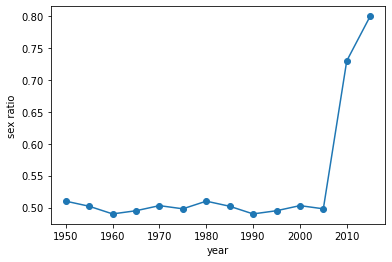

```
year= [1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015]
sex_ratio = [0.51, 0.502, 0.49, 0.495, 0.503, 0.498, 0.51, 0.502, 0.49, 0.495, 0.503, 0.498, 0.73, 0.80]
```

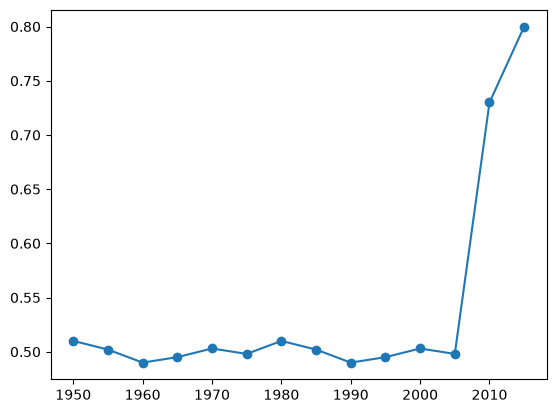

In [47]:
year= [1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015]
sex_ratio = [0.51, 0.502, 0.49, 0.495, 0.503, 0.498, 0.51, 0.502, 0.49, 0.495, 0.503, 0.498, 0.73, 0.80]
plt.plot(year,sex_ratio,'o-');

# Read more about this topic

While the above "data" in this notebook are completely fake, it was inspired by the paper [here](https://www.int-res.com/abstracts/meps/v621/p209-219), which was covered in the press [here](https://www.washingtonpost.com/world/africa/the-warming-climate-is-turning-baby-sea-turtles-one-gender/2019/10/21/d571f3fe-e3a6-11e9-b0a6-3d03721b85ef_story.html).

## Part 8 — Keyword arguments

### Q1

Write a function `power(base, exponent=2)` that returns `base` raised to the
power `exponent`. The `exponent` argument must **default to 2**, so that
`power(5)` returns `25`, while `power(2, 3)` returns `8` and
`power(3, exponent=3)` returns `27`.

In [48]:
def power(base, exponent=2):
    return base ** exponent

In [49]:
# If this runs without error, it means the answer in your previous cell was correct.
assert ads_hash(power(5)) == 'b7a56873cd'
assert ads_hash(power(2, 3)) == '2c624232cd'
assert ads_hash(power(3, exponent=3)) == '670671cd97'

## Part 9 — String formatting with f-strings

Remember from lecture various ways of formatting strings with template in Python. We are going to use f-strings here. 

Here is an example:

```python
city="Freiburg"
continent="Europe"
result = f"The city {city} is in the continent {continent}"
```

This will set `result` to `'The city Freiburg is in the continent Europe'`.

### Q1

Create a function named `greeting` which takes two arguments, `name` and `age`. It should return a string with these values inserted in to a string so that when called like

```python
result = greeting("Andrew",7)
```

`result` will be `'Hello. My name is Andrew. My age is 7'`.

The function signature will be

```python
def greeting(name, age):
```

In [50]:
def greeting(name, age):
    return f"Hello. My name is {name}. My age is {age}"

In [51]:
# If this runs without error, it means the answer in your previous cell was correct.

assert ads_hash(greeting("Andrew",7))=='1370611a0d'
assert ads_hash(greeting("Bob",47))=='3b8fd03444'

## Part 10 — Reading a CSV file

Step 1: Download file from https://archive.ics.uci.edu/ml/datasets/Wine+Quality . Click the "Download" button to get the `wine+quality.zip` file. Open this file and extract `winequality-red.csv`. Place it in the folder alongside this notebook.

Let's look at the first lines of this file.

In [52]:
!pwd
# on windows, try !cwd

/Users/andrew/Documents/src/wm01-fire-horse-instructor/exercises/source/exercise-02


In [53]:
!ls
# on windows, try !dir

1 - Control Flow and Data Structures.ipynb
winequality-red.csv


In [54]:
fobj = open('winequality-red.csv')
for line_num, line in enumerate(fobj.readlines()):
    line = line.strip()
    print(f"line {line_num}: '{line}'")
    if line_num > 3:
        break

line 0: '"fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'
line 1: '7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5'
line 2: '7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5'
line 3: '7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5'
line 4: '11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58;9.8;6'


### Q1 Read the file into a dict called `data`

The dict should have a key for each column in the CSV file and each dictionary value should be a list with all the values in that column.

For example, a CSV file like this:

```
name,home planet
Arthur,Earth
Zaphod,Betelgeuse V
Trillian,Earth
```

Would result in a dictionary like this:

```python
{'name':['Arthur','Zaphod','Trillian'], 'home planet':['Earth', 'Betelgeuse V', 'Earth']}
```

But here, we read the file `winequality-red.csv` which you have uploaded into this folder. Note that in this wine quality "CSV" file, the values are separated with semicolons (`;`), not commas.

In [55]:
fobj = open('winequality-red.csv')
data = {}
for line_num, line in enumerate(fobj.readlines()):
    line = line.strip()
    #print(f"line {line_num}: '{line}'")
    entries = line.split(';')
    if line_num == 0:
        column_names = entries
        for column_name in column_names:
            data[column_name] = []
        continue
    for (colname, entry) in zip(column_names, entries):
        data[colname].append(float(entry))
data.keys()

dict_keys(['"fixed acidity"', '"volatile acidity"', '"citric acid"', '"residual sugar"', '"chlorides"', '"free sulfur dioxide"', '"total sulfur dioxide"', '"density"', '"pH"', '"sulphates"', '"alcohol"', '"quality"'])

In [56]:
assert len(data.keys()) == 12
assert len(data['"alcohol"'])==1599
acc = 0; [acc := acc+x for x in data['"quality"']]
assert acc==9012

 ### Q2 Plot "Alcohol" (Y axis) versus "Density" (X axis).
 
 Your plot should look like this:
 
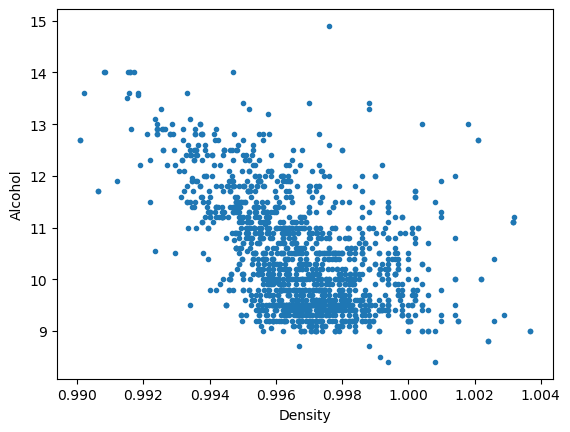

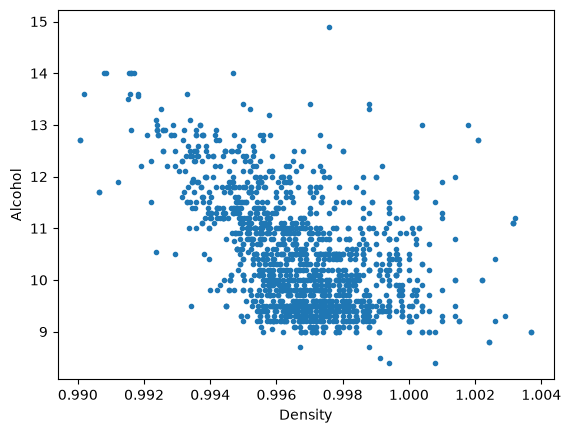

In [57]:
import matplotlib.pyplot as plt
plt.plot(data['"density"'], data['"alcohol"'], '.')
plt.xlabel("Density")
plt.ylabel("Alcohol");

# Uploading the exercise

Upload this `.ipynb` file to ILIAS. **Do not rename the file.** Make sure you
have run every cell (top to bottom) so that your answers and any plots are
saved in the notebook before you upload it.

You do **not** need to upload `winequality-red.csv` or `red_wine.png`.